In [1]:
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize

In [27]:
env = DummyVecEnv([lambda: gym.make("HalfCheetah-v4")])
env = VecNormalize(env, norm_obs=True, norm_reward=False, clip_obs=10.)

In [28]:
model = PPO("MlpPolicy", env, verbose=1)

Using cuda device


In [29]:
model.learn(total_timesteps=100000)

-----------------------------
| time/              |      |
|    fps             | 1406 |
|    iterations      | 1    |
|    time_elapsed    | 1    |
|    total_timesteps | 2048 |
-----------------------------
----------------------------------------
| time/                   |            |
|    fps                  | 1114       |
|    iterations           | 2          |
|    time_elapsed         | 3          |
|    total_timesteps      | 4096       |
| train/                  |            |
|    approx_kl            | 0.01341675 |
|    clip_fraction        | 0.106      |
|    clip_range           | 0.2        |
|    entropy_loss         | -8.51      |
|    explained_variance   | -0.00171   |
|    learning_rate        | 0.0003     |
|    loss                 | 11.1       |
|    n_updates            | 10         |
|    policy_gradient_loss | -0.0206    |
|    std                  | 0.999      |
|    value_loss           | 32.9       |
----------------------------------------
-----------

In [30]:
model.save("ppo_halfcheetah")
env.save("vecnormalize_halfcheetah.pkl")
del model
del env

In [31]:
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

In [32]:
model = PPO.load("ppo_halfcheetah")
eval_env = VecNormalize.load("vecnormalize_halfcheetah.pkl", DummyVecEnv([lambda: gym.make("HalfCheetah-v4")]))
eval_env.training = False

total_rewards = 0.0
num_steps = 1000
obs = eval_env.reset()

for _ in range(num_steps):
    action, _states = model.predict(obs, deterministic=True)
    obs, rewards, dones, info = eval_env.step(action)
    total_rewards += rewards

eval_env.close()

average_reward = total_rewards / num_steps
total_rewards_value = total_rewards.item()
average_reward_value = average_reward.item()

print("--- Evaluation Complete ---")
print(f"Total reward over {num_steps} steps: {total_rewards_value:.2f}")
print(f"Average reward per step: {average_reward_value:.2f}")

--- Evaluation Complete ---
Total reward over 1000 steps: 1185.67
Average reward per step: 1.19


In [33]:
action

array([[-1.        ,  1.        , -0.00691548, -0.81444776, -1.        ,
        -0.34194446]], dtype=float32)

In [34]:
obs

array([[ 2.3025248e+00, -3.1230979e+00, -2.4022567e-01, -7.2195731e-02,
         1.2516345e-04,  3.5435766e-02,  3.4052216e-02,  1.7739189e-01,
        -3.7988237e-01,  5.7452489e-02,  8.1996597e-02, -4.0345881e-03,
         2.0724602e-02,  1.6451712e-03,  1.3173674e-02,  7.5815897e-03,
        -4.3653091e-03]], dtype=float32)

# Reacher env

In [4]:
import gymnasium as gym
import numpy as np
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import matplotlib.pyplot as plt

class ReacherRewardWrapper(gym.Wrapper):
    def __init__(self, env, control_cost_weight=1.0):
        super().__init__(env)
        self.control_cost_weight = control_cost_weight

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        reward_dist = info['reward_dist']
        reward_ctrl = info['reward_ctrl']
        new_reward = reward_dist + self.control_cost_weight * reward_ctrl
        return obs, new_reward, terminated, truncated, info

CONTROL_WEIGHTS_TO_TRAIN = [0, 1, 2, 3, 4, 5]

TOTAL_TIMESTEPS = 1000000  

print(f"--- Starting automated training for {len(CONTROL_WEIGHTS_TO_TRAIN)} models ---")

for weight in CONTROL_WEIGHTS_TO_TRAIN:
    print("\n" + "="*50)
    print(f"STARTING TRAINING FOR: control_cost_weight = {weight}")
    print("="*50)

    model_filename = f"ppo_reacher_weight_{weight}"
    env_filename = f"vec_normalize_reacher_weight_{weight}.pkl"

    def make_reacher_env():
        env = gym.make("Reacher-v4")
        env = ReacherRewardWrapper(env, control_cost_weight=weight)
        return env

    train_env = DummyVecEnv([make_reacher_env])
    train_env = VecNormalize(train_env, norm_obs=True, norm_reward=False, clip_obs=10.)

    model = PPO("MlpPolicy", train_env, verbose=1, device="cpu")
    model.learn(total_timesteps=TOTAL_TIMESTEPS)

    model.save(model_filename)
    train_env.save(env_filename)
    train_env.close()

    print(f"\n--- COMPLETED training for weight = {weight} ---")
    print(f"Model saved to: {model_filename}.zip")
    print(f"Env stats saved to: {env_filename}")

print("\n" + "="*50)
print("All training runs are complete.")
print("="*50)

--- Starting automated training for 6 models ---

STARTING TRAINING FOR: control_cost_weight = 0
Using cpu device


-----------------------------
| time/              |      |
|    fps             | 2313 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1721         |
|    iterations           | 2            |
|    time_elapsed         | 2            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0064120293 |
|    clip_fraction        | 0.0463       |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.83        |
|    explained_variance   | -0.131       |
|    learning_rate        | 0.0003       |
|    loss                 | 0.262        |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00623     |
|    std                  | 0.994        |
|    value_loss           | 2.43         |
----------------

--- Loading all policies ---
Loading model for weight: 0
Loading model for weight: 1
Loading model for weight: 2
Loading model for weight: 3
Loading model for weight: 4
Loading model for weight: 5

--- Running comparison for 1000 steps ---
Driver policy is the one trained with weight = 1


--- Plotting action distributions ---


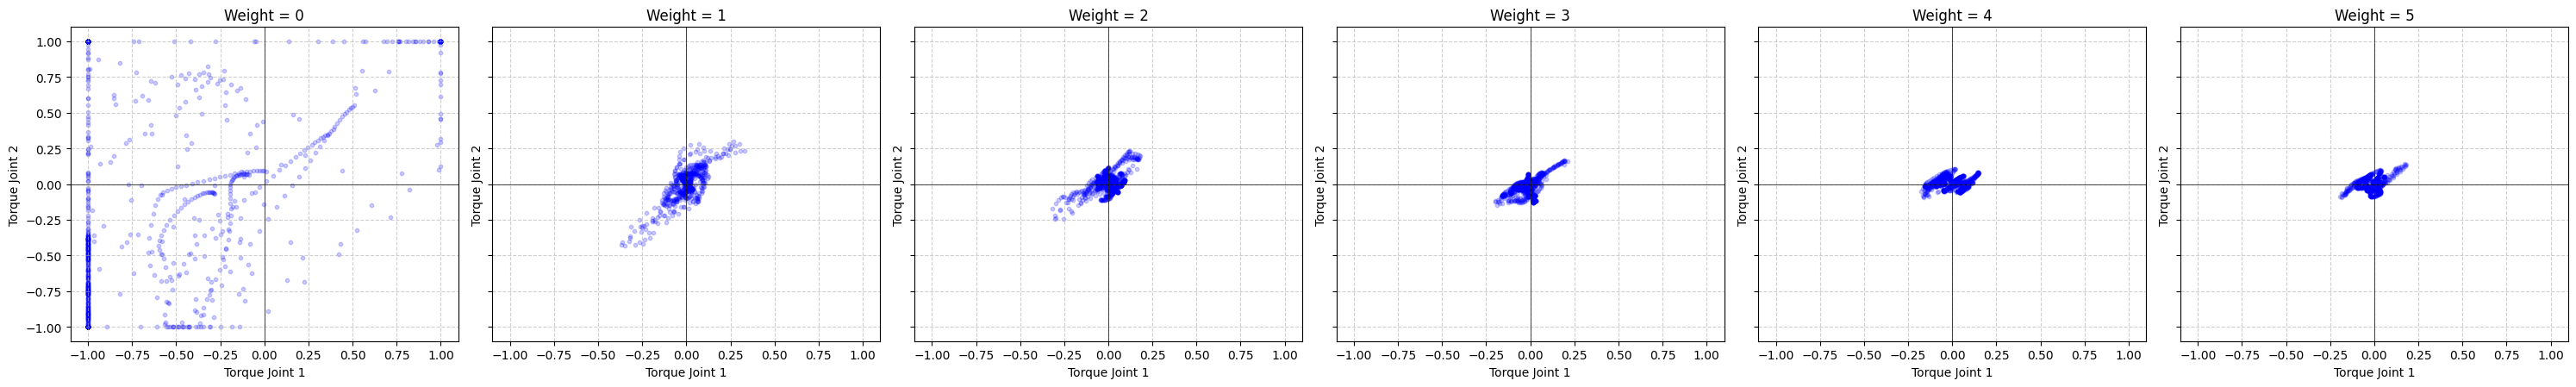

In [27]:
POLICY_CONFIG = {
    0: "ppo_reacher_weight_0",
    1: "ppo_reacher_weight_1",
    2: "ppo_reacher_weight_2",
    3: "ppo_reacher_weight_3",
    4: "ppo_reacher_weight_4",
    5: "ppo_reacher_weight_5",
}
DRIVER_WEIGHT = 1
DRIVER_MODEL_FILE = POLICY_CONFIG[DRIVER_WEIGHT]
DRIVER_ENV_FILE = f"vec_normalize_reacher_weight_{DRIVER_WEIGHT}.pkl"
NUM_COMPARISON_STEPS = 1000

print("--- Loading all policies ---")
loaded_policies = {}
for weight, filename in POLICY_CONFIG.items():
    print(f"Loading model for weight: {weight}")
    loaded_policies[weight] = PPO.load(filename, device="cpu")

def make_reacher_env():
    env = gym.make("Reacher-v4")
    env = ReacherRewardWrapper(env, control_cost_weight=DRIVER_WEIGHT)
    return env

eval_env = VecNormalize.load(DRIVER_ENV_FILE, DummyVecEnv([make_reacher_env]))
eval_env.training = False

print(f"\n--- Running comparison for {NUM_COMPARISON_STEPS} steps ---")
print(f"Driver policy is the one trained with weight = {DRIVER_WEIGHT}")
actions_log = {weight: [] for weight in POLICY_CONFIG.keys()}
obs_log = []

obs = eval_env.reset()
for _ in range(NUM_COMPARISON_STEPS):
    obs_log.append(obs.flatten())
    for weight, policy in loaded_policies.items():
        action, _ = policy.predict(obs, deterministic=True)
        actions_log[weight].append(action.flatten())

    driver_action, _ = loaded_policies[DRIVER_WEIGHT].predict(obs, deterministic=True)
    obs, _, _, _ = eval_env.step(driver_action)

eval_env.close()

for weight in actions_log:
    actions_log[weight] = np.array(actions_log[weight])

obs_log = np.array(obs_log)

print("--- Plotting action distributions ---")
num_policies = len(POLICY_CONFIG)
fig, axes = plt.subplots(1, num_policies, figsize=(num_policies * 5, 5), sharex=True, sharey=True)
plot_color = 'blue'

for ax, weight in zip(axes, sorted(POLICY_CONFIG.keys())):
    actions = actions_log[weight]
    
    ax.scatter(actions[:, 0], actions[:, 1], alpha=0.2, s=10, c=plot_color)
    
    ax.set_title(f'Weight = {weight}')
    ax.set_xlabel('Torque Joint 1')
    ax.set_ylabel('Torque Joint 2')
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [28]:
actions.shape

(1000, 2)

In [29]:
actions_log

{0: array([[ 1.        ,  1.        ],
        [ 1.        ,  0.7758044 ],
        [ 1.        ,  0.49415198],
        ...,
        [-1.        , -0.901959  ],
        [-1.        , -0.8890278 ],
        [-1.        , -0.8751626 ]], dtype=float32),
 1: array([[0.13705425, 0.23504323],
        [0.11142024, 0.19282405],
        [0.08596446, 0.16089162],
        ...,
        [0.00154988, 0.00123242],
        [0.00197989, 0.00072191],
        [0.00230159, 0.00030129]], dtype=float32),
 2: array([[ 0.15980057,  0.1084274 ],
        [ 0.12743899,  0.08225013],
        [ 0.09927566,  0.06243643],
        ...,
        [-0.00220474,  0.11466394],
        [-0.00332241,  0.11409952],
        [-0.00458013,  0.11332669]], dtype=float32),
 3: array([[ 0.08756649,  0.03530139],
        [ 0.06672402,  0.01896605],
        [ 0.04614487,  0.00345428],
        ...,
        [-0.14603893, -0.07337788],
        [-0.14517015, -0.07243194],
        [-0.14434327, -0.07149489]], dtype=float32),
 4: array([[ 0.1

In [30]:
obs_log

array([[ 0.8001682 ,  1.1881468 , -0.03798818, ..., -0.01417907,
        -1.6678514 ,  0.        ],
       [ 0.80011284,  1.1869719 , -0.02928292, ..., -0.01564671,
        -1.6307214 ,  0.        ],
       [ 0.79963076,  1.1829494 , -0.00501814, ..., -0.02123895,
        -1.5270022 ,  0.        ],
       ...,
       [ 0.18468186, -0.66199726,  1.0912492 , ..., -0.84985244,
        -0.3221961 ,  0.        ],
       [ 0.19407019, -0.64987946,  1.0840458 , ..., -0.8438132 ,
        -0.3283748 ,  0.        ],
       [ 0.20300922, -0.63786554,  1.0771015 , ..., -0.8378216 ,
        -0.33406556,  0.        ]], dtype=float32)

In [31]:
# for each weight in action log, concat the observations to the actions
for weight in actions_log:
    actions_log[weight] = np.concatenate((actions_log[weight], obs_log), axis=1)

In [36]:
import torch
torch.save(torch.tensor(actions_log[1]), "reacher_data_1.pt")
torch.save(torch.tensor(actions_log[2]), "reacher_data_2.pt")
torch.save(torch.tensor(actions_log[3]), "reacher_data_3.pt")
torch.save(torch.tensor(actions_log[4]), "reacher_data_4.pt")
torch.save(torch.tensor(actions_log[5]), "reacher_data_5.pt")

--- Evaluating each policy in its own environment ---

Evaluating policy for weight = 0...


/home/azureuser/miniconda/envs/dtr/lib/python3.10/site-packages/stable_baselines3/common/vec_env/base_vec_env.py:78: UserWarning: The `render_mode` attribute is not defined in your environment. It will be set to None.
  warnings.warn("The `render_mode` attribute is not defined in your environment. It will be set to None.")



Evaluating policy for weight = 1...

Evaluating policy for weight = 2...

Evaluating policy for weight = 3...

Evaluating policy for weight = 4...

Evaluating policy for weight = 5...

--- Plotting action distributions ---


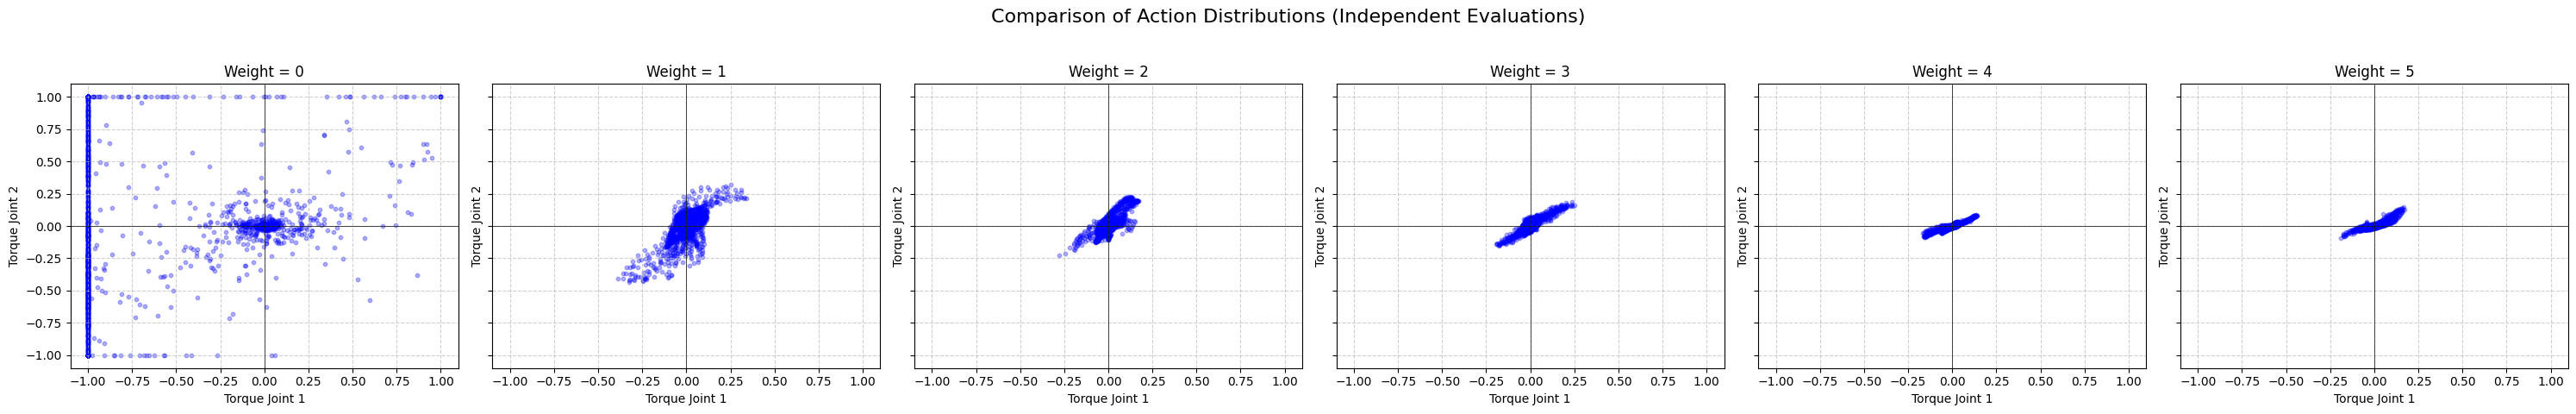

In [7]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize

# --- The Custom Wrapper (needed for loading the environment correctly) ---
class ReacherRewardWrapper(gym.Wrapper):
    def __init__(self, env, control_cost_weight=1.0):
        super().__init__(env)
        self.control_cost_weight = control_cost_weight

    def step(self, action):
        # This wrapper logic is required to correctly load the saved environment,
        # even if we don't use the modified reward during this analysis.
        obs, reward, terminated, truncated, info = self.env.step(action)
        reward_dist = info['reward_dist']
        reward_ctrl = info['reward_ctrl']
        new_reward = reward_dist + self.control_cost_weight * reward_ctrl
        return obs, new_reward, terminated, truncated, info

# --- Configuration ---
POLICY_CONFIG = {
    0: "ppo_reacher_weight_0",
    1: "ppo_reacher_weight_1",
    2: "ppo_reacher_weight_2",
    3: "ppo_reacher_weight_3",
    4: "ppo_reacher_weight_4",
    5: "ppo_reacher_weight_5",
}
NUM_EVAL_STEPS = 2000

# --- Part 1: Evaluate each policy in its own environment ---
print("--- Evaluating each policy in its own environment ---")
actions_log = {weight: [] for weight in POLICY_CONFIG.keys()}

for weight, model_filename_base in POLICY_CONFIG.items():
    print(f"\nEvaluating policy for weight = {weight}...")
    
    # Load the specific model
    model = PPO.load(model_filename_base, device="cpu")
    
    # Load the corresponding environment statistics
    # This is crucial as each policy was trained with different normalization
    env_filename = f"vec_normalize_reacher_weight_{weight}.pkl"
    
    def make_reacher_env():
        env = gym.make("Reacher-v4")
        # Weight must match training to ensure wrapper compatibility
        env = ReacherRewardWrapper(env, control_cost_weight=weight)
        return env

    eval_env = VecNormalize.load(env_filename, DummyVecEnv([make_reacher_env]))
    eval_env.training = False

    # Run evaluation loop for this specific policy
    obs = eval_env.reset()
    for _ in range(NUM_EVAL_STEPS):
        action, _ = model.predict(obs, deterministic=True)
        obs, _, _, _ = eval_env.step(action)
        actions_log[weight].append(action.flatten())
    
    eval_env.close()

# Convert lists of actions to numpy arrays
for weight in actions_log:
    actions_log[weight] = np.array(actions_log[weight])

# --- Part 2: Plot the Action Distributions ---
print("\n--- Plotting action distributions ---")
num_policies = len(POLICY_CONFIG)
fig, axes = plt.subplots(1, num_policies, figsize=(num_policies * 5, 5), sharex=True, sharey=True)
fig.suptitle('Comparison of Action Distributions (Independent Evaluations)', fontsize=16)

plot_color = 'blue'

for ax, weight in zip(axes, sorted(POLICY_CONFIG.keys())):
    actions = actions_log[weight]
    
    ax.scatter(actions[:, 0], actions[:, 1], alpha=0.3, s=10, c=plot_color)
    
    ax.set_title(f'Weight = {weight}')
    ax.set_xlabel('Torque Joint 1')
    ax.set_ylabel('Torque Joint 2')
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()